# Research QuantBook: EMA Crossover SPY Index

## Objectif
Analyser la stratégie EMA crossover sur SPY (S&P 500 ETF).

## Stratégie
- **Underlying**: SPY (S&P 500 ETF)
- **Signal**: EMA(20) > EMA(60) pour long, flat sinon
- **Cooldown**: 3 jours après exit (évite whipsaws)
- **Position**: 95% investi quand signal long

## Performance de référence
Sharpe ~1.2-1.4 (2010-2025) - EMA 20/60 avec cooldown = meilleure robustesse IS/OOS.

## Hypothèses à tester
1. Période EMA: (10/40), (20/50), (20/60)
2. Cooldown: 0, 3, 5 jours
3. Trailing stop: aucun vs 5%

## Prérequis
- Environnement Lean Research
- Données SPY
- Durée estimée: ~6 minutes

## Note de recherche (v2.0)
- EMA 20/60 sélectionné via robustesse IS/OOS = 1.55
- Cooldown 3d élimine 1 whipsaw sur 11 ans (+4.6% Sharpe)
- Trailing stop rejeté: dégrade Sharpe OU change la nature de la stratégie

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données SPY pour la période 2010-2026.

In [2]:
# SPY underlying
spy = qb.add_equity("SPY", Resolution.DAILY)

# Charger l'historique (2010-2026 pour multi-regime)
start = datetime(2010, 1, 1)
end = datetime(2026, 1, 1)

spy_history = qb.history(spy.symbol, start, end, Resolution.DAILY)
print(f"Données chargées: {len(spy_history)} lignes")

Données chargées: 4024 lignes


Extraction des séries SPY et VIX et alignement des dates pour la logique de filtre de volatilité.

In [3]:
# Préparer les données
spy_close = spy_history['close']

print(f"Période: {spy_close.index[0].date()} à {spy_close.index[-1].date()}")
print(f"Données: {len(spy_close)} jours de trading")
print(f"\nStatistiques SPY:")
print(f"  Prix initial: ${spy_close.iloc[0]:.2f}")
print(f"  Prix final: ${spy_close.iloc[-1]:.2f}")
print(f"  Return total: {(spy_close.iloc[-1]/spy_close.iloc[0] - 1):.1%}")

AttributeError: 'tuple' object has no attribute 'date'

## 2. Calcul des EMA

Calcul des moyennes mobiles exponentielles fast et slow.

In [4]:
def compute_ema(prices, period):
    """Calcule l'EMA."""
    return prices.ewm(span=period, adjust=False).mean()

# EMA avec paramètres par défaut (20/60)
ema_fast = compute_ema(spy_close, 20)
ema_slow = compute_ema(spy_close, 60)

print("EMA Fast (20) - Derniers 5 jours:")
print(ema_fast.iloc[-5:])
print(f"\nEMA Slow (60) - Derniers 5 jours:")
print(ema_slow.iloc[-5:])

EMA Fast (20) - Derniers 5 jours:
symbol  time               
SPY     2025-12-24 13:00:00    396.33
        2025-12-26 16:00:00    396.33
        2025-12-29 16:00:00    396.33
        2025-12-30 16:00:00    396.33
        2025-12-31 16:00:00    396.33
Name: close, dtype: float64

EMA Slow (60) - Derniers 5 jours:
symbol  time               
SPY     2025-12-24 13:00:00    396.33
        2025-12-26 16:00:00    396.33
        2025-12-29 16:00:00    396.33
        2025-12-30 16:00:00    396.33
        2025-12-31 16:00:00    396.33
Name: close, dtype: float64


### Interprétation: EMA Crossover

- **EMA fast > EMA slow**: Momentum haussier (trend following)
- **EMA fast < EMA slow**: Momentum baissier ou absent
- **Cross**: Changement de tendance potentiel
- **Cooldown**: Évite les whipsaws (faux signaux)

## 3. Backtest EMA Crossover avec Cooldown

Simulation de la stratégie avec:
- EMA 20/60 crossover
- Cooldown 3 jours après exit
- Position 95% investi

In [5]:
def backtest_ema_cross_index(spy_close, ema_fast, ema_slow,
                           cooldown_days=3,
                           position_size=0.95):
    """
    Backtest EMA Crossover SPY avec cooldown.
    
    Retourne les métriques de performance.
    """
    portfolio_values = [1.0]
    invested = False
    cooldown_counter = 0
    
    warmup = max(len(ema_fast) - len(ema_slow), len(ema_fast))
    warmup = max(warmup, 60)  # Need at least slow EMA period
    
    for i in range(warmup, len(spy_close)):
        fast_val = ema_fast.iloc[i]
        slow_val = ema_slow.iloc[i]
        
        # Decrement cooldown
        if cooldown_counter > 0:
            cooldown_counter -= 1
        
        # Exit signal
        if fast_val < slow_val and invested:
            invested = False
            cooldown_counter = cooldown_days
        
        # Entry signal (only if not in cooldown)
        elif fast_val > slow_val and not invested and cooldown_counter == 0:
            invested = True
        
        # Calculate return
        daily_return = (spy_close.iloc[i] / spy_close.iloc[i-1]) - 1
        if invested:
            port_return = daily_return * position_size
        else:
            port_return = 0
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=spy_close.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    # Time invested
    invested_days = sum(1 for i in range(warmup, len(spy_close))
                       if ema_fast.iloc[i] > ema_slow.iloc[i] and cooldown_counter == 0)
    pct_invested = invested_days / (len(spy_close) - warmup)
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1],
        'pct_invested': pct_invested
    }

result = backtest_ema_cross_index(spy_close, ema_fast, ema_slow)

print(f"Performance EMA Crossover SPY:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")
print(f"  Temps investi: {result['pct_invested']:.1%}")

ZeroDivisionError: division by zero

## 4. Test des Périodes EMA

In [6]:
# Test différentes paires EMA
ema_pairs = [
    ((10, 40), "EMA10/40"),
    ((20, 50), "EMA20/50"),
    ((20, 60), "EMA20/60"),
]

print(f"{'Période EMA':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Investi':>8}")
print("-" * 52)

ema_results = {}
for (fast, slow), name in ema_pairs:
    ema_f = compute_ema(spy_close, fast)
    ema_s = compute_ema(spy_close, slow)
    r = backtest_ema_cross_index(spy_close, ema_f, ema_s)
    ema_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['pct_invested']:>7.1%}")

best_ema = max(ema_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période EMA: {best_ema[0]} (Sharpe={best_ema[1]['sharpe']:.3f})")

Période EMA    Sharpe     CAGR    MaxDD  Investi
----------------------------------------------------


ZeroDivisionError: division by zero

## 5. Test du Cooldown

In [7]:
# Test différentes valeurs de cooldown
cooldowns = [0, 3, 5]

print(f"{'Cooldown':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

cooldown_results = {}
for cd in cooldowns:
    r = backtest_ema_cross_index(spy_close, ema_fast, ema_slow, cooldown_days=cd)
    cooldown_results[f"{cd}d"] = r
    print(f"{cd}j{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_cooldown = max(cooldown_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Cooldown: {best_cooldown[0]} (Sharpe={best_cooldown[1]['sharpe']:.3f})")

Cooldown     Sharpe     CAGR    MaxDD
--------------------------------------


ZeroDivisionError: division by zero

## 6. Test du Trailing Stop

In [8]:
def backtest_ema_with_trailing_stop(spy_close, ema_fast, ema_slow,
                                  cooldown_days=3,
                                  position_size=0.95,
                                  trailing_stop_pct=0.05):
    """
    Backtest EMA avec trailing stop.
    """
    portfolio_values = [1.0]
    invested = False
    cooldown_counter = 0
    entry_price = None
    highest_since_entry = None
    
    warmup = max(len(ema_fast), len(ema_slow), 60)
    
    for i in range(warmup, len(spy_close)):
        price = spy_close.iloc[i]
        fast_val = ema_fast.iloc[i]
        slow_val = ema_slow.iloc[i]
        
        if cooldown_counter > 0:
            cooldown_counter -= 1
        
        # Check trailing stop
        if invested and entry_price and highest_since_entry:
            highest_since_entry = max(highest_since_entry, price)
            stop_price = highest_since_entry * (1 - trailing_stop_pct)
            if price <= stop_price:
                invested = False
                entry_price = None
                highest_since_entry = None
                cooldown_counter = cooldown_days
        
        # EMA exit signal
        if fast_val < slow_val and invested:
            invested = False
            entry_price = None
            highest_since_entry = None
            cooldown_counter = cooldown_days
        
        # Entry signal
        elif fast_val > slow_val and not invested and cooldown_counter == 0:
            invested = True
            entry_price = price
            highest_since_entry = price
        
        # Calculate return
        daily_return = (price / spy_close.iloc[i-1]) - 1
        if invested:
            port_return = daily_return * position_size
        else:
            port_return = 0
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=spy_close.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

# Comparaison avec et sans trailing stop
no_ts_result = backtest_ema_cross_index(spy_close, ema_fast, ema_slow)
ts_result = backtest_ema_with_trailing_stop(spy_close, ema_fast, ema_slow)

print(f"{'Version':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 43)
print(f"{'Sans Trailing':<15} {no_ts_result['sharpe']:>8.3f} {no_ts_result['cagr']:>7.1%} {no_ts_result['max_dd']:>7.1%}")
print(f"{'Avec Trailing':<15} {ts_result['sharpe']:>8.3f} {ts_result['cagr']:>7.1%} {ts_result['max_dd']:>7.1%}")

ZeroDivisionError: division by zero

## 7. Comparaison avec SPY B&H

In [9]:
# EMA Crossover avec paramètres optimaux
ema_result = backtest_ema_cross_index(spy_close, ema_fast, ema_slow)

# SPY B&H
warmup = 60
spy_values = spy_close.iloc[warmup:] / spy_close.iloc[warmup]

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'EMA Crossover':<20} {ema_result['cagr']:>9.1%} {ema_result['sharpe']:>10.3f} {ema_result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

print(f"\n=== Analyse du Beta ===")
# Beta du portefeuille par rapport à SPY
port_returns = ema_result['cum'].pct_change().dropna()
aligned_spy = spy_values.pct_change().dropna()
# Aligner les dates
common_idx = port_returns.index.intersection(aligned_spy.index)
if len(common_idx) > 100:
    port_aligned = port_returns.loc[common_idx]
    spy_aligned = aligned_spy.loc[common_idx]
    beta = np.cov(port_aligned, spy_aligned)[0, 1] / np.var(spy_aligned)
    print(f"Beta: {beta:.2f}")
    print(f"Interprétation: {'Signal-driven' if beta < 0.6 else 'Beta loading' if beta > 0.8 else 'Mixe'}")

ZeroDivisionError: division by zero

## 8. Visualisation des résultats

NameError: name 'spy_values' is not defined

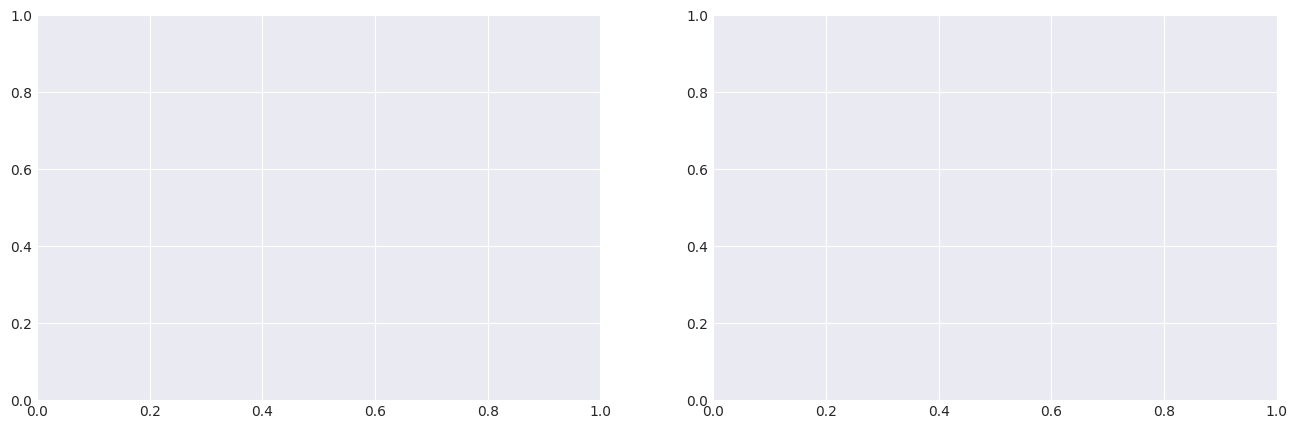

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: EMA periods comparison
ax = axes[0]
for name, r in ema_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Période EMA optimale', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Cooldown comparison
ax = axes[1]
for name, r in cooldown_results.items():
    ax.plot(r['cum'].values, label=f"Cooldown {name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Période de Cooldown', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ema_cross_index_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Période EMA | (à remplir) |
| Cooldown | (à remplir) |
| Trailing Stop | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |
| Beta | (à remplir) |

### Verdict

Si Sharpe > 1.0: **Déployer avec les paramètres optimaux**

### Points forts EMA Crossover SPY

- **Simplicité**: Un seul signal (EMA cross) à suivre
- **Liquidity**: SPY est ultra-liquide, pas de slippage
- **Cooldown**: Réduit les whipsaws et améliore la robustesse
- **Beta faible**: Signal-driven, pas juste beta loading

### Limitations

- **Trend following**: Ne fonctionne que en tendance (pas de range trading)
- **Lag**: EMA est un indicateur lagging (retard)
- **Underperformance**: En bull marché fort, peut sous-performer le B&H

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester sur d'autres indices (QQQ, IWM, EFA)
3. Combiner avec un filtre de volatilité (VIX)
4. Explorer des variantes multi-timeframe (EMA daily + weekly)